In [1]:
from IPython.display import HTML, display

# Hide all top headers, toolbars, and checkpoint status lines in Jupyter Notebook 7
display(
    HTML("""
<style>
    /* Hides top panel, menu bar, title, and checkpoint text */
    #jp-top-panel,
    #jp-main-statusbar,
    div.jp-Notebook-header,
    .jp-NotebookToolbar,
    #jp-MenuPanel,
    .jp-Cell-inputHeader {
        display: none !important;
    }
</style>
""")
)

# Solving Math Problems with SageMath

interactive Jupyter Notebook slides: 
 <a href="https://github.com/manfredscheucher/talk-sageintro">Download</a> or
 <a href="https://colab.research.google.com/?authuser=2">Try now with Google Colab!</a>

<img src="figs/arrangement.png" width="30%">

<!-- NOTE: keep this Contents list in sync with the 4 PART divider slides (## titles). Edit both when renaming a part. -->

### Contents
1. Getting Started
2. Calculus & Algebra
3. Geometry & Graphs
4. Logic & Optimization



---

# PART 1 of 4
## Getting Started

---

<!-- NOTE: part title must match the Contents list on the title slide. -->

---
# SageMath

* Free software for solving mathematical problems
  * [try it out online](https://sagecell.sagemath.org/)
  * [install Sage](https://doc.sagemath.org/html/en/installation/index.html) (6–10 GB disk space)
  * [CoCalc](https://cocalc.ai/) for collaborating with others and/or an AI agent
* combines the strengths of open-source libraries such as
  * **PARI/GP, FLINT, NTL** — number theory
  * **GAP, Singular** — group and ring theory
  * **Maxima, SymPy** — symbolic algebra, calculus
  * **GLPK** — linear/integer optimization
  * **NumPy/SciPy** — numerical
  * **NetworkX, Boost, Nauty** — graphs
  * **Matplotlib, Three.js, Jmol** — 2D/3D plots
* unified Python interface
  * large parts in Cython (performance, C/C++ bindings)
  * also R, Octave, Mathematica, ... usable
* extensive documentation with examples
    * [SageMath documentation](https://doc.sagemath.org/)
    * [SageMath tutorial (PDF)](https://doc.sagemath.org/pdf/en/tutorial/SageTutorial.pdf)

---
## Why not just C/C++ or Python?

**C/C++ — integer overflow:**
```c
int x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 0  (overflow!)
```

**C++ with GMP** (GNU Multiple Precision Arithmetic Library) — arbitrarily large integers:
```c
#include <gmpxx.h>
mpz_class x = 1;
for (int i = 0; i < 100; i++) x *= 2;
// → 1267650600228229401496703205376
```

**Python** — big integers out of the box:
```python
2**100  # → 1267650600228229401496703205376
```

**But — floating point:**
```c
#include <cmath>
float  x = sqrt(2.0f); printf("%.20f\n", x*x); // → 1.99999988079071044922
double x = sqrt(2.0);  printf("%.20f\n", x*x); // → 2.00000000000000044409
```

```python
import math
x = math.sqrt(2.0)
print(x*x)  # → 2.0000000000000004
```


Irrational numbers can't be represented as floats — but this is where it gets interesting!

## Irrational Numbers: Algebraic vs. Transcendental

### Algebraic numbers

* roots of polynomials with integer coefficients:
    - $\sqrt{2}$ is a root of $x^2 - 2$
    - $\sqrt[3]{5}$ is a root of $x^3 - 5$
    - $\sqrt{2}+1$ is a root of $(x-1)^2 - 2=x^2-2x-1$

* the polynomial representation allows **exact** computation

* **SageMath handles this for you!**


**Example:**
```python
sqrt(6) / sqrt(2)   # → sqrt(3)
```

Internal computation $z = x/y$ with $x^2 = 6$, $y^2 = 2$ $\;\Rightarrow\;$ $z^2 = x^2/y^2 = 6/2 = 3$, so the minimal polynomial is $z^2 - 3$.

**More complex example:** $x = \sqrt{2}+\sqrt{3}$

$$\begin{align}
x - \sqrt{2} &= \sqrt{3} \\
(x-\sqrt{2})^2 &= 3 \\
x^2 - 2x\sqrt{2} + 2 &= 3 \\
x^2 - 1 &= 2x\sqrt{2} \\
(x^2-1)^2 &= 8x^2 \\
x^4 - 10x^2 + 1 &= 0
\end{align}$$

```python
(sqrt(2)+sqrt(3)).minpoly()  # → x^4 - 10*x^2 + 1
```

### Transcendental numbers

* no such polynomial exists for $\pi$, $e$, $\sin(1)$, ...

* but: well-known identities are available symbolically in Sage:
```python
sin(pi)    # → 0
sin(pi/2)  # → 1
```
* Sage even recognizes limits/sequences/series:
```python
n = var('n')
limit((1 + 1/n)^n, n=oo)  # → e
```

```python
n, x = var('n x')
sum(x^n / factorial(n), n, 0, oo)  # → e^x
```

*  Commercial tools like Wolfram Mathematica/Alpha can do this too, of course — but Sage is OSS! Anyone who wants to can read all the way down to the source and follow every step.

---
# Basics

How do you use "sage"?
* Jupyter Notebook `sage --notebook` or `sage -n` # <-- used throughout this presentation!
* command-line interface `sage`
* script with arguments `sage script.sage`

In [2]:
print("Hello World!") # Python input/output
print("Hello Sage!")

Hello World!
Hello Sage!


In [3]:
"Hello World!" 
"Hello Sage!" # Jupyter Notebook shows the last one

'Hello Sage!'

In [4]:
def f(x): return x*x
print([f(x) for x in range(10)]) # functions, list comprehension, etc.

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]


In [5]:
def my_generator():
    s = 'hello'
    while True:
        yield s
        s += 'X'

g = my_generator()
for i in range(10): print(i,next(g)) # generators

0 hello
1 helloX
2 helloXX
3 helloXXX
4 helloXXXX
5 helloXXXXX
6 helloXXXXXX
7 helloXXXXXXX
8 helloXXXXXXXX
9 helloXXXXXXXXX


**Overview of objects and methods**

In [6]:
G=Graph()
G?

In [7]:
#G.<tab>     ->  list of attributes and methods
G.is_connected?

**Measuring time in Jupyter**

In [8]:
%%time 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) 

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 2.66 s, sys: 56 ms, total: 2.71 s
Wall time: 5.33 s


In [9]:
%%time
@cached_function 
def fib(x): return x if x<=1 else fib(x-1)+fib(x-2)
print([fib(x) for x in range(32)]) # dynamic programming: store intermediate results

[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584, 4181, 6765, 10946, 17711, 28657, 46368, 75025, 121393, 196418, 317811, 514229, 832040, 1346269]
CPU times: user 221 μs, sys: 187 μs, total: 408 μs
Wall time: 409 μs


**Command-line arguments**
* can also be run from the command line: `sage script.sage` or `time sage script.sage`
* arguments via `argv` or `argparse`

```python
# https://docs.python.org/3/library/argparse.html
parser.add_argument('filename') # mandatory filename
parser.add_argument('-c', '--count', type=int) # optional integer
parser.add_argument('-v', '--verbose', action='store_true') # optional flag
```

**Multithreading**

In [10]:
%%time 
import time
def f(i): 
    time.sleep(float(0.1)) 
    return i
print([f(i) for i in range(50)]) # 5 seconds on 1 CPU (single-threaded)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 4.63 ms, sys: 6.87 ms, total: 11.5 ms
Wall time: 5.23 s


In [11]:
%%time 
@parallel
def f(i): 
    time.sleep(float(0.1)) 
    return i
print(list(f(range(50)))) # 0.1 seconds (parallelized in Jupyter)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
CPU times: user 468 μs, sys: 1.26 ms, total: 1.73 ms
Wall time: 106 ms


Side remarks:
* in this example even `print(list(f(range(1000))))` takes only 0.1 sec since there is no busy wait!
* for a Sage script use `multiprocessing.Pool.map`, see [pool_example.sage](pool_example.sage)

In [12]:
# measuring time and parallelization on the command line
!sage pool_example.sage 

21:10:18.896 single-thread start


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
21:10:24.189 single-thread stop


21:10:24.982 parallel start


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
21:11:41.230 parallel stop


---

# PART 2 of 4
## Calculus & Algebra

---

<!-- NOTE: part title must match the Contents list on the title slide. -->

---
# Number Theory & Cryptography

In [13]:
x = 1337
print(x.is_prime())
print(x.factor())
print(next_prime(x))
# list of methods by typing: x.<tab>

False
7 * 191
1361


**Modular arithmetic** (RSA and other cryptosystems):

$$2^{12} \mod 17 = \;?$$


In [14]:
power_mod(2, 12, 17)
# 2^12 = 2^(4*3) = (2^4)^3 = 16^3 = (-1)^3 = -1 = 16 mod 17

16

Detailed functions and docs on **ECC** (Elliptic Curve Cryptography):

<a href="https://doc.sagemath.org/html/en/reference/arithmetic_curves/index.html">arithmetic curves reference</a>

---
# Curve Sketching

Classic high-school exam problems

In [15]:
# example 1
x = var('x')
f = 1-x^2
print(f) # textual output
f.show() # formatted output

-x^2 + 1


-x^2 + 1

In [16]:
print("f'(x) =", f.diff()) # symbolic derivative
print("F(x)  =", f.integrate(x)) # antiderivative

f'(x) = -2*x


F(x)  = -1/3*x^3 + x


In [17]:
f.roots() # roots with multiplicities

[(-1, 1), (1, 1)]

In [18]:
f.find_local_maximum(-1,1) # numerical search for a local maximum, returns y value first, then x value

(1.0, 4.933333305577758e-09)

In [19]:
f.diff().roots() # extrema, symbolically

[(0, 1)]

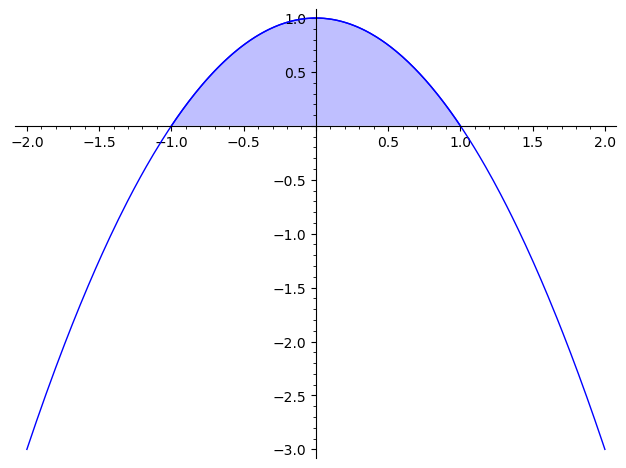

In [20]:
# plot: area under the curve
p  = plot(f, (x, -2, 2))
p += plot(f, (x, -1, 1), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [21]:
# area computation
I = integrate(f, x, -1, 1)
print(f"Area: {I} ≈ {float(I)}") # computed symbolically, result converted to numeric

Area: 4/3 ≈ 1.3333333333333333


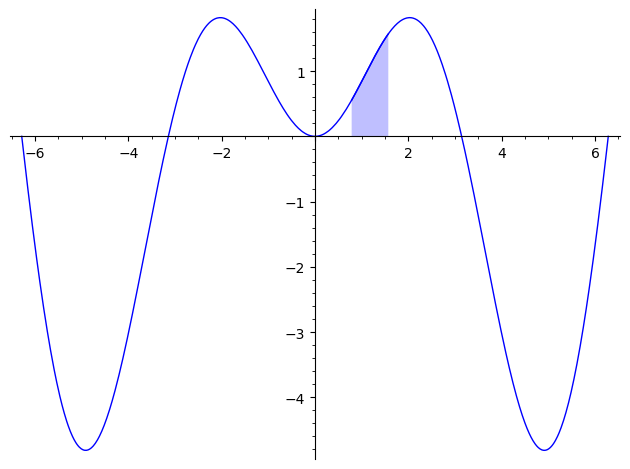

In [22]:
# example 2: elementary functions (sine, cosine, ...)
f = x*sin(x)

p  = plot(f, (x, -2*pi, 2*pi))
p += plot(f, (x, pi/4, pi/2), fill=True, fillcolor="blue", fillalpha=0.25)
p.show()

In [23]:
f.find_local_maximum(0,pi) # y value first, then x value

(1.819705741159653, 2.0287578390054044)

In [24]:
# area computation
I = integrate(f, x, pi/4, pi/2)
print(f"Area: {I} ≈ {float(I)}") # computed symbolically, result converted to numeric

Area: 1/8*sqrt(2)*pi - 1/2*sqrt(2) + 1 ≈ 0.8482535860832482


In [25]:
# arbitrary precision (number of bits)
for prec in [30,100,300,1000]:
    R = RealField(prec)
    print(f"{prec} \t-> {R(I)}")

30 	-> 0.84825359
100 	-> 0.84825358608324825647614076165
300 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722100
1000 	-> 0.848253586083248256476140761652737673041991773483487241297334581874188109906380719396722099681774868302919353470197450408082531786867834830224857546409333962203298519505731895261281732387086924235670892379900332787149289022340125581320941646902546785000861569051624975354245554175904560251983112700234


**Remark**: even when no symbolic result exists, you can raise the working precision (bits) until the numerical result is within a desired tolerance!

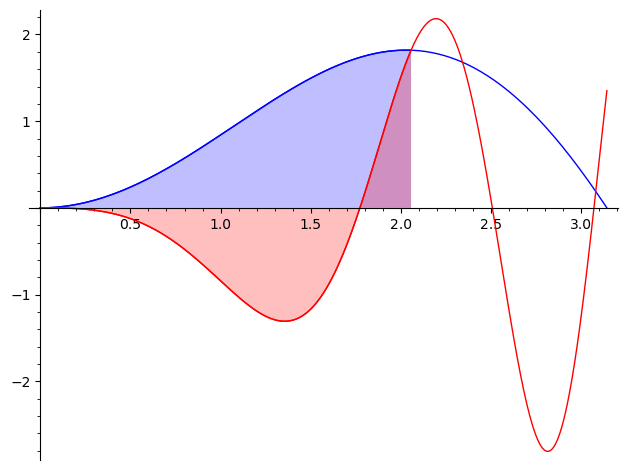

In [26]:
# plot: area between curves 
f = x*sin(x)
g = -x*sin(x*x)

x1 = (f-g).find_root(2,2.3)
p  = plot(f, (x, 0, pi), color='blue')
p += plot(f, (x, 0, x1), color='blue', fill=True, fillcolor='blue', fillalpha=0.25)

p += plot(g, (x, 0, pi), color='red')
p += plot(g, (x, 0, x1), color='red', fill=True, fillcolor='red', fillalpha=0.25)
p.show()

In [27]:
print((f-g).find_root(2,2.3)) # numerical search for intersections of f and g
print((f-g).find_root(2.3,3))
print((f-g).find_root(3,3.5))

2.0560096453612196
2.3416277185114787
3.0799958958578673


In [28]:
(f-g).roots() # finds only x=0 as a root
# the others come from the transcendental equation sin(x)=-sin(x²), no polynomial, not solvable symbolically

[(0, 1)]

In [29]:
# symbolic area computation
I = integrate(f-g, x, pi/4, pi/2)
print(f"Area: {I} ≈ {float(I)}")

Area: 1/8*sqrt(2)*pi - 1/2*sqrt(2) - 1/2*cos(1/4*pi^2) + 1/2*cos(1/16*pi^2) + 1 ≈ 1.6467117908494968


---
# Systems of Equations

**Intersection of two lines:** $2x+y=4$, $x+2y=4$:

In [30]:
x, y = var('x y')
solve([2*x+y==4,x+2*y==4],x,y) # (4/3, 4/3)

[[x == (4/3), y == (4/3)]]

Or, a bit more cumbersome:
$$A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}, \quad b = \begin{pmatrix} 4 \\ 4 \end{pmatrix}, \quad Ax = b \;\Rightarrow\; x = A^{-1} b$$

sol: (4/3, 4/3)


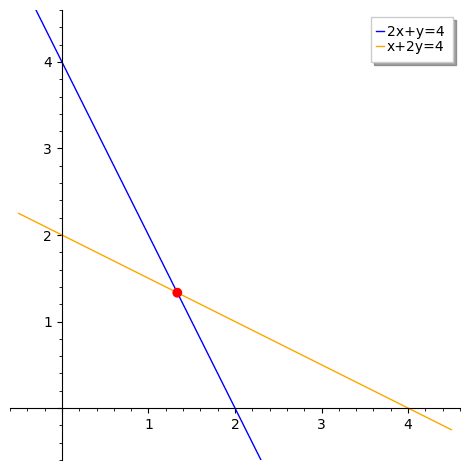

In [31]:
A = matrix([[2,1],[1,2]])
b = vector([4,4])
sol = A.inverse() * b # (4/3, 4/3)
print(f"sol: {sol}")

x = var('x')
p  = plot(4 - 2*x, (x, -0.5, 3), color='blue',   legend_label='2x+y=4')
p += plot(2 - x/2, (x, -0.5, 4.5), color='orange', legend_label='x+2y=4')
p += point(sol, size=50, color='red', zorder=5)
p.show(aspect_ratio=1, xmin=-0.5, xmax=4.5, ymin=-0.5, ymax=4.5)

**Intersection of two circles:**

$$C_1: (x-1)^2 + y^2 = 4 \qquad C_2: (x+1)^2 + y^2 = 4$$

In [32]:
x, y = var('x y')
C1 = (x-1)^2 + y^2 == 4
C2 = (x+1)^2 + y^2 == 4

In [33]:
solutions = solve([C1, C2], x, y) # symbolic intersection points
print(solutions)

[
[x == 0, y == -sqrt(3)],
[x == 0, y == sqrt(3)]
]


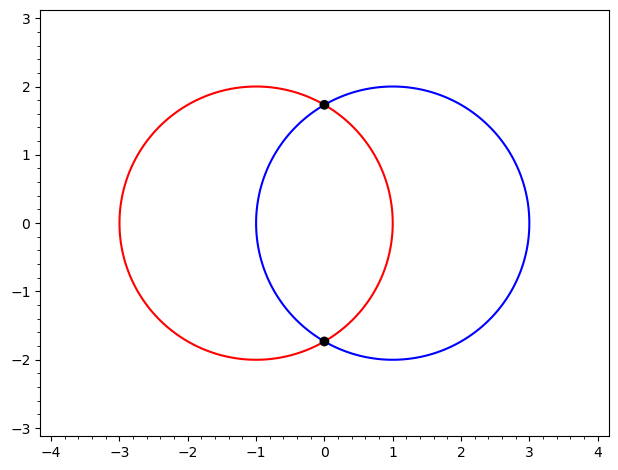

In [34]:
p  = implicit_plot(C1.lhs() - C1.rhs(), (x, -4, 4), (y, -3, 3), color='blue')
p += implicit_plot(C2.lhs() - C2.rhs(), (x, -4, 4), (y, -3, 3), color='red')
for s in solutions:
    sx = s[0].rhs()
    sy = s[1].rhs()
    p += point((RR(sx), RR(sy)), size=50, color='black', zorder=2)
p.show(aspect_ratio=1)

**Idea behind the symbolic solution:**

In [35]:
# every intersection point (x,y) is a root of both equations 
f1 = (x-1)^2 + y^2 - 4 
f2 = (x+1)^2 + y^2 - 4 

In [36]:
# ... and a root of f3 = f1-f2
f3 = (f1-f2)
print(f3) 
print(f3.simplify_full()) # 4x is zero only when x=0 

-(x + 1)^2 + (x - 1)^2
-4*x


In [37]:
# ... and a root of f4 = f1+f2, in particular when x=0 is substituted
f4 = (f1+f2)
print(f4)
print(f4(x=0))
print(f4(x=0).roots())

(x + 1)^2 + (x - 1)^2 + 2*y^2 - 8
2*y^2 - 6
[(-sqrt(3), 1), (sqrt(3), 1)]


**Note**: finding real solutions is hard in general (between NP and PSPACE)
[existential theory of the reals (Wikipedia)](https://en.wikipedia.org/wiki/Existential_theory_of_the_reals)

---

# PART 3 of 4
## Geometry & Graphs

---

<!-- NOTE: part title must match the Contents list on the title slide. -->

---
# Geometry

Visualize 2D and 3D structures with just a few lines of code

**Example:**

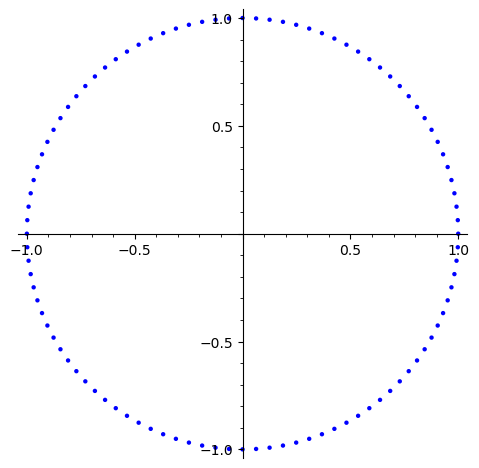

In [38]:
n = 100
point2d([(cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)]).show(aspect_ratio=1)

In [39]:
p = point3d([(cos(x*2*pi/n),sin(x*2*pi/n),0) for x in range(n)],color='blue')
p += point3d([(cos(x*2*pi/n),0,sin(x*2*pi/n)) for x in range(n)],color='red')
p += point3d([(0,cos(x*2*pi/n),sin(x*2*pi/n)) for x in range(n)],color='green')
p.show(aspect_ratio=1)

Graphics3d Object

In [40]:
import random
from scipy.spatial import Voronoi, ConvexHull

def new_points():
    return [(random.uniform(0,1), random.uniform(0,1)) for _ in range(20)]

pts = new_points()
hull2d = ConvexHull(pts)
hull_indices = set(hull2d.vertices)

@interact
def geo_demo(mode=selector(['Nearest Neighbor', 'Voronoi', 'Convex Hull'], label='Mode')):
    global pts, hull2d, hull_indices
    hull2d = ConvexHull(pts)
    hull_indices = set(hull2d.vertices)

    inner = [pts[i] for i in range(len(pts)) if i not in hull_indices]
    outer = [pts[i] for i in hull_indices]

    p = points(inner, size=30, color='black', zorder=5)
    p += points(outer, size=30, color='blue', zorder=5)

    if mode == 'Nearest Neighbor':
        for i, (ax, ay) in enumerate(pts):
            best = min((j for j in range(len(pts)) if j != i),
                       key=lambda j: (pts[j][0]-ax)**2 + (pts[j][1]-ay)**2)
            bx, by = pts[best]
            p += arrow((ax, ay), (bx, by), color='blue', width=1, arrowsize=2)

    elif mode == 'Voronoi':
        vor = Voronoi(pts)
        for simplex in vor.ridge_vertices:
            if -1 not in simplex:
                x0, y0 = vor.vertices[simplex[0]]
                x1, y1 = vor.vertices[simplex[1]]
                p += line([(x0,y0),(x1,y1)], color='red')

    elif mode == 'Convex Hull':
        hull_pts = [pts[i] for i in hull2d.vertices]
        p += polygon(hull_pts, color='lightblue', alpha=0.5)
        p += line(hull_pts+[hull_pts[0]], color='blue', thickness=2)

    p.show(axes=False, frame=True, xmin=-0.05, xmax=1.05, ymin=-0.05, ymax=1.05)

Interactive function <function geo_demo at 0x16b2bb4c0> with 1 widget
  mode: Dropdown(description='Mode', options=('Nearest Neighbor', 'Voronoi', 'Convex Hull'), value='Nearest Neighbor')

In [41]:
# many geometric shapes such as the icosahedron are available
I = polytopes.icosahedron()
print("Vertices:", len(I.vertices()))
print("Faces:", len(I.faces(2)))
I.plot()

python3(23285) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Vertices: 12


Faces: 20


Graphics3d Object

In [42]:
import random
from scipy.spatial import ConvexHull
import numpy as np

random.seed()  # system time
pts3 = [(random.uniform(-1,1), random.uniform(-1,1), random.uniform(-1,1)) for _ in range(30)]
arr3 = np.array(pts3)

hull3 = ConvexHull(arr3)
hull_idx3 = set(hull3.vertices)

p3 = point3d([pts3[i] for i in hull_idx3], size=10, color='blue')
p3 += point3d([pts3[i] for i in range(len(pts3)) if i not in hull_idx3], size=10, color='black')

for simplex in hull3.simplices:
    tri = [pts3[i] for i in simplex]
    p3 += polygon3d(tri, color='lightblue', alpha=0.3)

p3.show()

Graphics3d Object

**3D pseudo-hyperplane arrangement:**

[lasagne3d/example_pshyperplanes.html](lasagne3d/example_pshyperplanes.html)

[3D signotope arrangements (viewer gallery)](https://helenabergold.github.io/supp/3d_signotopes/)

# Arrangements in the plane and on the sphere

Circles on a sphere map to circles in the plane under **stereographic projection** from the north pole $P$: two circles meeting in $A, B$ project to two circles meeting in $A', B'$.

[en.wikipedia.org/wiki/Stereographic_projection](https://en.wikipedia.org/wiki/Stereographic_projection) — drag to rotate the figure below.

In [43]:
# notebook-cell candidate: self-contained, ends with fig.show() for interactive viewer
import numpy as np

def unit(v):
    v = np.array(v, float); return v/np.linalg.norm(v)
def ortho_frame(n):
    n = unit(n)
    a = np.array([1.0,0,0]) if abs(n[0])<0.9 else np.array([0,1.0,0])
    u = unit(a - (a@n)*n); v = np.cross(n,u); return n,u,v
def small_circle_point(n,c,theta):
    n,u,v = ortho_frame(n); rho = np.sqrt(1-c*c)
    return c*n + rho*(np.cos(theta)*u + np.sin(theta)*v)
def project(Q):
    Q = np.array(Q,float); P = np.array([0,0,1.0]); t = 2.0/(1.0-Q[2]); return P + t*(Q-P)
def line_sphere(n1,c1,n2,c2):
    n1=unit(n1);n2=unit(n2)
    G = np.array([[n1@n1,n1@n2],[n2@n1,n2@n2]]); ab = np.linalg.solve(G,[c1,c2])
    p0 = ab[0]*n1+ab[1]*n2; d = unit(np.cross(n1,n2))
    b = 2*(p0@d); cc = p0@p0-1; disc = b*b-4*cc
    s1=(-b+np.sqrt(disc))/2; s2=(-b-np.sqrt(disc))/2
    return p0+s1*d, p0+s2*d
def circle3(p1,p2,p3):
    p1,p2,p3=[np.array(p,float) for p in (p1,p2,p3)]
    (x1,y1),(x2,y2),(x3,y3)=p1[:2],p2[:2],p3[:2]
    A=np.array([[x2-x1,y2-y1],[x3-x1,y3-y1]]); rhs=0.5*np.array([x2*x2-x1*x1+y2*y2-y1*y1, x3*x3-x1*x1+y3*y3-y1*y1])
    cx,cy=np.linalg.solve(A,rhs); R=np.hypot(cx-x1,cy-y1); return np.array([cx,cy,-1.0]),R

# asymmetric circles so A,B,C,D are irregularly placed (not mirror-symmetric)
nR=unit([0.3,0.3,-0.8]); cR=0.25
nB=unit([0.3,0.6,-0.75]); cB=0.45
P=np.array([0,0,1.0])
A3,B3=line_sphere(nR,cR,nB,cB)
C3=small_circle_point(nR,cR,0.6); D3=small_circle_point(nB,cB,2.0)
Ap,Bp,Cp,Dp=project(A3),project(B3),project(C3),project(D3)
redCenter,redR=circle3(Ap,Bp,Cp); blueCenter,blueR=circle3(Ap,Bp,Dp)

RED=(0.85,0.12,0.12); BLUE=(0.12,0.30,0.85); DARK=(0.08,0.08,0.08)
# Visual tuning (geometry/asserts untouched):
CIRCLE_TH=3      # on-sphere tori + projected circles (was 6 -> halved)
RAY_TH=4         # rays P->A'..D' (was 1 -> thicker)
POINT_SZ=26      # fat dots, ~2x the circle tube thickness (was 16)
fig=Graphics()
# yellow, still transparent so inner circles/points stay visible
fig+=sphere((0,0,0),1,color=(1.0,0.90,0.15),opacity=0.30,mesh=False)
S=3.0
fig+=polygon3d([(-S,-S,-1),(S,-S,-1),(S,S,-1),(-S,S,-1)],color=(0.70,0.80,0.95),opacity=0.15)
# solid border so the plane z=-1 is visible even in the raytracer (transparent faces render faintly)
fig+=line3d([(-S,-S,-1),(S,-S,-1),(S,S,-1),(-S,S,-1),(-S,-S,-1)],color=(0.4,0.5,0.7),thickness=2)
th=var('th')
def sc(n,c,col):
    nn,u,v=ortho_frame(n); rho=float(np.sqrt(1-c*c)); cn=[float(c)*float(nn[i]) for i in range(3)]
    return parametric_plot3d(tuple(cn[i]+rho*(cos(th)*float(u[i])+sin(th)*float(v[i])) for i in range(3)),(th,0,2*pi),color=col,thickness=CIRCLE_TH)
fig+=sc(nR,cR,RED); fig+=sc(nB,cB,BLUE)
def pc(center,R,col):
    cx,cy,cz=float(center[0]),float(center[1]),float(center[2]); R=float(R)
    return parametric_plot3d((cx+R*cos(th),cy+R*sin(th),cz),(th,0,2*pi),color=col,thickness=CIRCLE_TH)
fig+=pc(redCenter,redR,RED); fig+=pc(blueCenter,blueR,BLUE)
for Qp in [Ap,Bp,Cp,Dp]:
    fig+=line3d([tuple(P),tuple(Qp)],color=(0.55,0.55,0.55),thickness=RAY_TH)
# fat dots (added before labels)
def ptdot(coord,col):
    return point3d(tuple(coord),size=POINT_SZ,color=col)
fig+=ptdot(P,DARK); fig+=ptdot(A3,DARK); fig+=ptdot(B3,DARK)
fig+=ptdot(C3,RED); fig+=ptdot(D3,BLUE)
fig+=ptdot(Ap,DARK); fig+=ptdot(Bp,DARK)
fig+=ptdot(Cp,RED); fig+=ptdot(Dp,BLUE)
# labels LAST so they stay in the foreground; offsets nudge them outward/up
def lbl(coord,col,name,off):
    return text3d(name,tuple(np.array(coord,float)+np.array(off)),color=col,fontsize=22)
# larger offsets so letters sit clear of the fat dots, not inside them
fig+=lbl(P,DARK,"P",(0,0,0.32)); fig+=lbl(A3,DARK,"A",(0,0.30,0.22)); fig+=lbl(B3,DARK,"B",(0,-0.34,0.22))
fig+=lbl(C3,RED,"C",(0.30,0,0.22)); fig+=lbl(D3,BLUE,"D",(-0.36,0,0.22))
fig+=lbl(Ap,DARK,"A'",(0,0.34,0.22)); fig+=lbl(Bp,DARK,"B'",(0,-0.40,0.22))
fig+=lbl(Cp,RED,"C'",(0.36,0,0.22)); fig+=lbl(Dp,BLUE,"D'",(-0.44,0,0.22))
# No scene rotation: the z-axis points up, sphere at origin, plane z=-1 flat below.
# In the interactive viewer you rotate it yourself.
fig.show()

Graphics3d Object

A point $Q$ on the sphere is sent along the ray from the north pole $P=(0,0,1)$ to where it meets the plane $z=-1$:

$$Q \;\longmapsto\; P + \frac{2}{1-z_Q}\,(Q-P).$$

Circles not through $P$ map to circles, so the red/blue circles on the sphere become the red/blue circles in the plane.

## Complete Enumeration

**$n=3$**:

<img src=figs/pc3.png width=53%>


**$n=4$**:

<img src=figs/pc4.png width=75%>

## Grünbaum's Conjecture

* conjecture: $n$ pseudocircles $\Rightarrow$ at least $4n/3$ triangle cells
* complete enumeration only up to $n=7$ pseudocircles (20 GB)
* systematic extension to $n=8$
* counterexample with 8 pseudocircles and 8 triangle cells
    * [doi.org/10.1007/s00454-020-00173-4](https://doi.org/10.1007/s00454-020-00173-4)
* however **not realizable** (cannot be drawn with circles)
    * [doi.org/10.1007/s00454-019-00077-y](https://doi.org/10.1007/s00454-019-00077-y)

<img src=figs/arrangement.png width=34%><img src=figs/arrangement2.png width=34%>

[(0, 29), (0, 30), (0, 31), (1, 11), (1, 12), (1, 13), (2, 19), (2, 22), (2, 10), (3, 17), (3, 20), (3, 8), (4, 18), (4, 21), (4, 9), (5, 24), (5, 26), (5, 14), (6, 25), (6, 27), (6, 15), (7, 16), (7, 23), (7, 28), (8, 11), (8, 12), (8, 14), (9, 11), (9, 13), (9, 15), (10, 16), (10, 12), (10, 13), (11, 18), (12, 17), (13, 19), (14, 18), (14, 20), (15, 19), (15, 21), (16, 17), (16, 22), (17, 23), (18, 24), (19, 25), (20, 23), (20, 26), (21, 24), (21, 27), (22, 25), (22, 28), (23, 30), (24, 29), (25, 31), (26, 29), (26, 30), (27, 29), (27, 31), (28, 30), (28, 31)]


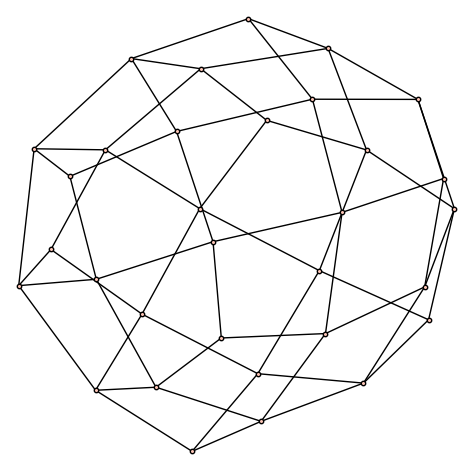

In [44]:
# dual graph of the arrangement as a sparse6 string
s = ":_gBca`GH`GI`HIdGeHfIbKOcJMaLNbMcNaOfPSdQTeRUdSeTfU_WYZ_VY[_XZ["
g = Graph(s)
print(g.edges(labels=False))
g.plot(vertex_size=10,vertex_labels=0).show() # drawn on the sphere ... not pretty

{26: [30, 1], 0: [0, 30], 30: [1, 0], 1: [14, 6], 2: [7, 5], 3: [4, 2], 4: [18, 10], 5: [28, 2], 6: [7, 16], 7: [2, 6], 8: [19, 3], 9: [9, 14], 10: [14, 4], 11: [14, 9], 12: [17, 3], 13: [11, 8], 14: [27, 2], 15: [8, 15], 16: [4, 4], 17: [4, 3], 18: [24, 5], 19: [7, 8], 20: [4, 1], 21: [10, 16], 22: [5, 5], 23: [3, 3], 24: [10, 19], 25: [5, 17], 27: [7, 17], 28: [1, 7], 29: [7, 23], 31: [1, 22]}


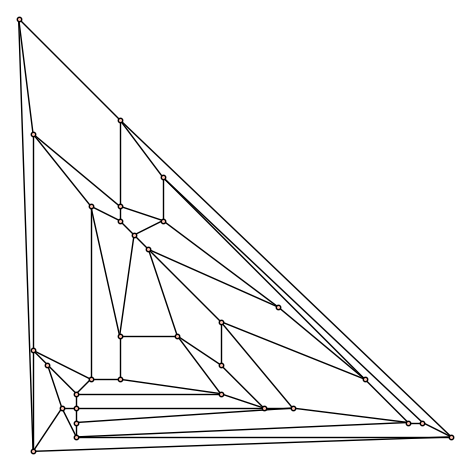

In [45]:
g.is_planar(set_pos=1)
print(g.get_pos()) 
g.plot(vertex_size=10,vertex_labels=0).show() # n-vertex graph on an n x n grid ... but not pretty

## Tutte Layout

A better layout for planar graphs: outer vertices fixed on a circle, inner vertices placed at the weighted barycenter of their neighbors.

article (open access):
[doi.org/10.1007/s00454-020-00173-4](https://doi.org/10.1007/s00454-020-00173-4)

source:
[github.com/manfredscheucher/tuttedraw](https://github.com/manfredscheucher/tuttedraw)

Gives aesthetic drawings for many families of planar graphs, such as pseudocircle arrangements — a good starting point. For publication I still nudge a few things by hand (what looks good is subjective) in the [IPE drawing editor](https://ipe-web.otfried.org/index.html) ([website](https://ipe.otfried.org/), also handy for LaTeX Beamer slides).

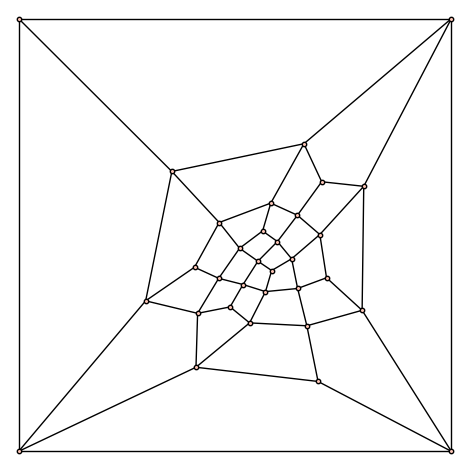

In [46]:
# https://github.com/manfredscheucher/tuttedraw/blob/main/draw.sage
def tutte_layout(G,outer_face,weights):
	V = G.vertices()
	pos = dict()
	l = len(outer_face)

	a0 = pi/l+pi/2
	for i in range(l):
		ai = a0+pi*2*i/l
		pos[outer_face[i]] = (cos(ai),sin(ai))
	
	n = len(V)
	M = zero_matrix(RR,n,n)
	b = zero_matrix(RR,n,2)

	for i in range(n):
		v = V[i]
		if v in pos:
			M[i,i] = 1
			b[i,0] = pos[v][0]
			b[i,1] = pos[v][1]
		else:
			nv = G.neighbors(v)
			s = 0
			for u in nv:
				j = V.index(u)
				wu = weights[u,v]
				s += wu
				M[i,j] = -wu
			M[i,i] = s

	sol = M.pseudoinverse()*b
	return {V[i]:sol[i] for i in range(n)}

outer_face = [v for v,_ in g.faces()[0]]
weights = {(u,v): 1 for u,v in g.edges(labels=False) for u,v in [(u,v),(v,u)]}
pos = tutte_layout(g, outer_face, weights)
g.plot(pos=pos,vertex_size=10,vertex_labels=0) # even nicer with tuned weights!

## Iterated Tutte

Tune the edge weights iteratively instead of using uniform weights:

* weight proportional to edge length **plus** the summed area of the two adjacent cells
* so long edges with large neighboring faces get pulled shorter

Below: iterations 1, 2, 4, 8, 16, 32 (doubling), so you can watch the drawing settle; Δw is the relative change of the weights from the previous step.

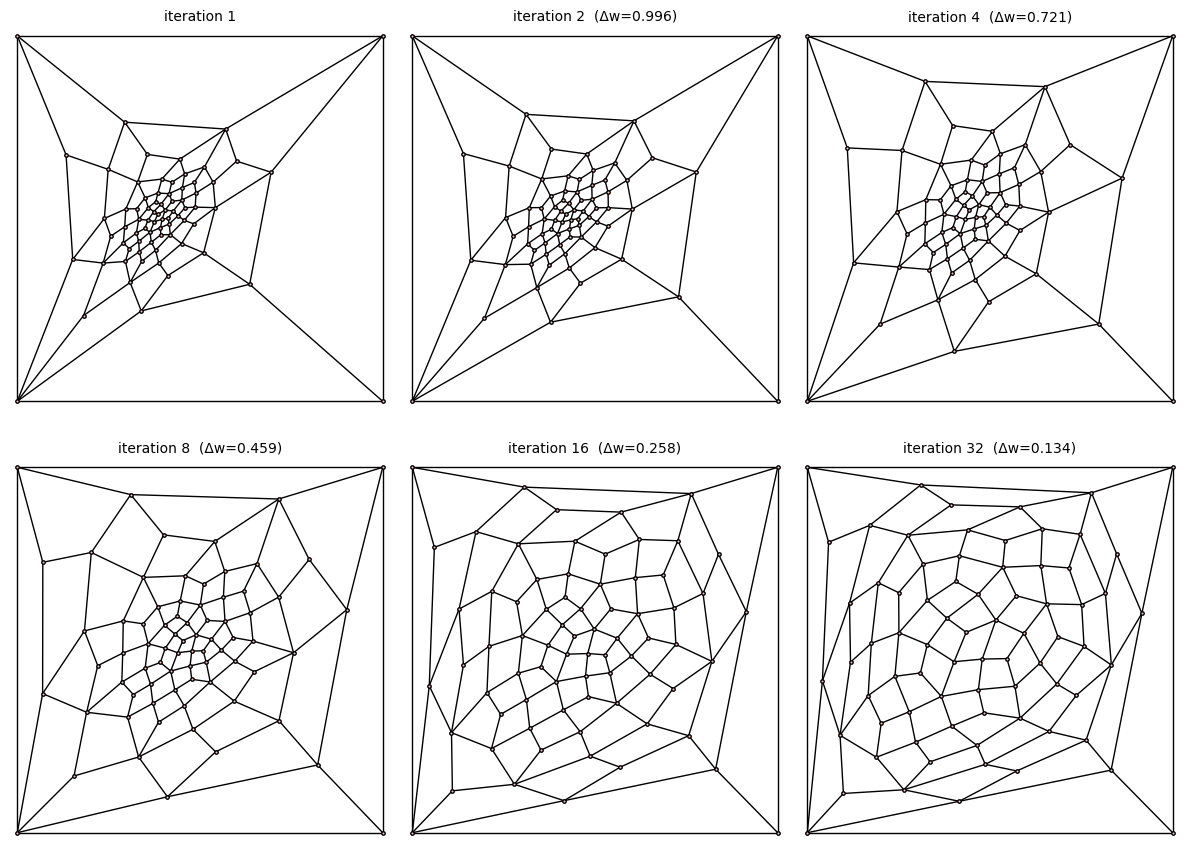

In [47]:
from scipy.spatial import ConvexHull

# a larger pseudocircle-arrangement dual graph, on its own so weights stay independent
g2 = Graph(":~?@I`_GD`WkI`WWK_O_Ic?}J_?eOd_[KcWmK`o}CEGKT`gKHDWGLEXUSDpe[FQAOhOQGA`_c`qIQeqY??OaPFqEGAQQPEHyA_oOmehWXea?fcagk_QMSDrUDFQ]NCq_pap]HHAy[FQSocP{nc@YFBruTIBCr`AOhJiCqNXG]NwOn_`sdOxklNCM?Cqa@AbWxc@OtOW?@CqN")
outer_face = [v for v, _ in g2.faces()[0]]

N = 32
show = [2^k for k in range(6)]   # show iterations 1, 2, 4, 8, 16, 32

# iteration 1: plain Tutte, all weights = 1
weights = {}
for u, v in g2.edges(labels=False):
    weights[u, v] = weights[v, u] = 1.0
pos = tutte_layout(g2, outer_face, weights)
frames = {1: (dict(pos), None)}   # iteration -> (positions, relative weight change)

eps = 0.1
for it in range(2, N+1):
    dist2 = lambda u, v: (pos[u][0]-pos[v][0])^2 + (pos[u][1]-pos[v][1])^2
    old = weights
    weights = {}
    for u, v in g2.edges(labels=False):
        w = RR(old[u, v] + eps*(dist2(u, v) - old[u, v]))   # move toward edge length
        weights[u, v] = weights[v, u] = w
    for f in g2.faces():                                     # add adjacent-cell area
        verts = [e[0] for e in f]
        try:
            area = RR(ConvexHull([pos[w] for w in verts]).volume)
            for a in range(len(verts)):
                u, v = verts[a], verts[(a+1) % len(verts)]
                add = float(it*area)^4
                weights[u, v] = weights.get((u, v), 0) + add
                weights[v, u] = weights.get((v, u), 0) + add
        except Exception:
            pass
    # relative change of the weight vector vs. the previous iteration
    edges = list(g2.edges(labels=False))
    w_old = vector([old[e] for e in edges])
    w_new = vector([weights[e] for e in edges])
    rel = RR((w_old - w_new).norm() / w_new.norm())
    pos = tutte_layout(g2, outer_face, weights)
    if it in show:
        frames[it] = (dict(pos), rel)

# show iterations 1, 2, 4, 8, 16, 32 (3 per row); title shows the relative weight change
plots = [g2.plot(pos=frames[k][0], vertex_size=6, vertex_labels=0,
                 title=(f"iteration {k}" if frames[k][1] is None else f"iteration {k}  (Δw={frames[k][1]:.3f})"))
         for k in show]
graphics_array(plots, ncols=3).show(figsize=12)

---
# Graphs

* a native graph library (Cython/C backend)  
* interfaces to the **Boost Graph Library** (C++) and **NetworkX** (Python).

Vertices: ['A', 'B', 'C', 'D', 'E', 'F']
Edges: [('A', 'B'), ('A', 'C'), ('A', 'D'), ('B', 'C'), ('B', 'E'), ('C', 'F'), ('D', 'E'), ('E', 'F')]
planar: True


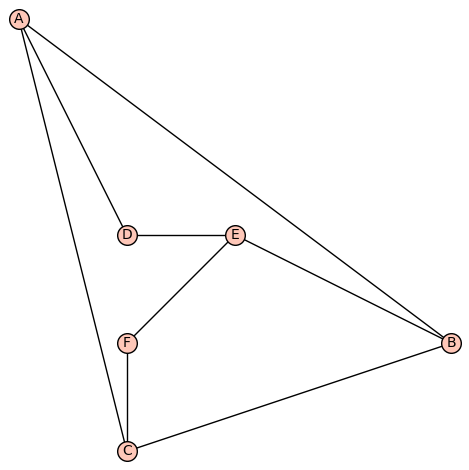

In [48]:
G = Graph({'A': ['B','C','D'], 'B': ['C','E'], 'C': ['F'], 'D': ['E'], 'E': ['F'], 'F': []})
print("Vertices:", G.vertices())
print("Edges:", G.edges(labels=False))
print("planar:", G.is_planar(set_pos=True)) # planar drawing if one exists, optional
G.plot()

Chromatic number: 3
Coloring: [['A', 'E'], ['B', 'D', 'F'], ['C']]


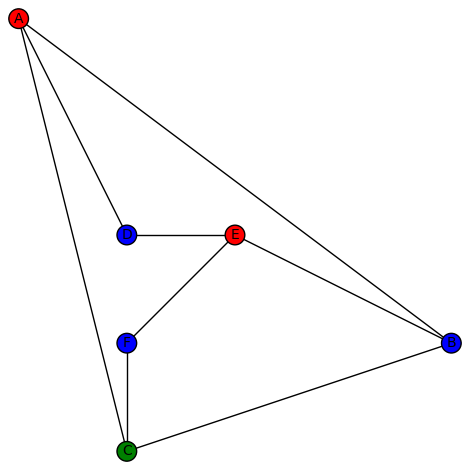

In [49]:
# graph coloring
chi = G.chromatic_number()
print("Chromatic number:", chi)

coloring = G.coloring()
print("Coloring:", coloring)

G.plot(vertex_colors={
    'red':   coloring[0],
    'blue':  coloring[1],
    'green': coloring[2] if len(coloring) > 2 else []
})

In [50]:
# shortest paths between all pairs of vertices
algo = choice(["BFS","Floyd-Warshall-Cython","Floyd-Warshall-Python","Dijkstra_NetworkX","Dijkstra_Boost","Johnson_Boost"])
# list of all algorithms via "G.distance_all_pairs?"

print("Algorithm:",algo)
D = G.distance_all_pairs(algorithm=algo)
vertices = sorted(G.vertices())

print("Distance matrix:")
header = "    " + "  ".join(f"{v:>3}" for v in vertices)
print(header)
for u in vertices:
    row = f"{u:>3} " + "  ".join(f"{D[u][v]:>3}" for v in vertices)
    print(row)

Algorithm: Floyd-Warshall-Python
Distance matrix:
      A    B    C    D    E    F
  A   0    1    1    1    2    2
  B   1    0    1    2    1    2
  C   1    1    0    2    2    1
  D   1    2    2    0    1    2
  E   2    1    2    1    0    1
  F   2    2    1    2    1    0


## Traveling Salesman (TSP)

Reuse the Tutte layout: weight each edge by the Euclidean distance between its endpoints, then find the shortest cycle visiting every vertex.

NP-hard in general; Sage solves it exactly (as a MILP). Here the graph `g` is Hamiltonian, so such a cycle exists.

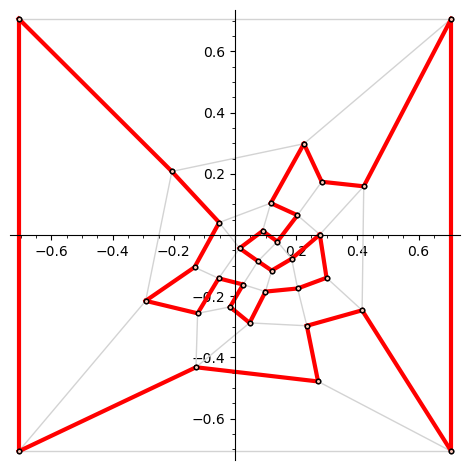

In [51]:
# Euclidean TSP on the Tutte-drawn graph g:
# edge weight = distance between its endpoints in the layout, then find the optimal cycle
pos_g = tutte_layout(g, [v for v, _ in g.faces()[0]],
                     {(u, v): 1 for u, v in g.edges(labels=False) for u, v in [(u, v), (v, u)]})
for u, v in g.edges(labels=False):
    d = (vector(pos_g[u]) - vector(pos_g[v])).length()
    g.set_edge_label(u, v, d)

tour = g.traveling_salesman_problem(use_edge_labels=True)   # optimal Hamiltonian cycle

# draw: all edges faint in the background, optimal cycle thick + red on top
plt  = g.plot(pos=pos_g, vertex_size=10, vertex_labels=0, edge_color='lightgray')
plt += tour.plot(pos=pos_g, vertex_size=10, vertex_labels=0, edge_color='red', edge_thickness=3)
plt.show()

---

# PART 4 of 4
## Logic & Optimization

---

<!-- NOTE: part title must match the Contents list on the title slide. -->

---
# Linear Programming (LP)

a mathematical method for optimizing a linear objective function subject to linear constraints

**Example:**
$$\max\; x + y$$

$$\begin{align}
\text{s.t.} \quad 2x + y &\leq 4 \quad (1)\\
x + 2y &\leq 4 \quad (2)\\
x, y &\geq 0
\end{align}$$

In [52]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(nonnegative=True)

p.set_objective(x[1] + x[2])
p.add_constraint(2*x[1] +   x[2] <= 4)
p.add_constraint(  x[1] + 2*x[2] <= 4)

p.solve()
print(f"x = {RR(p.get_values(x[1]))}")
print(f"y = {RR(p.get_values(x[2]))}")
print(f"z (objective) = {RR(p.get_objective_value())}")

x = 1.33333333333333
y = 1.33333333333333
z (objective) = 2.66666666666667


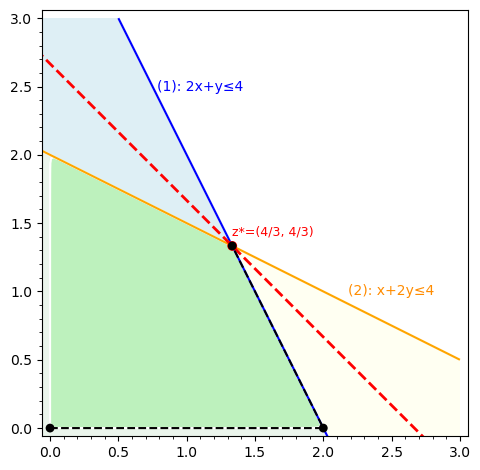

In [53]:
# graphical representation of the constraints and feasible region
x, y = var('x y')

r1 = region_plot(2*x + y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightblue', alpha=0.4)
r2 = region_plot(x + 2*y <= 4, (x, -0.5, 3), (y, -0.5, 3), incol='lightyellow', alpha=0.4)
r3 = region_plot([x >= 0, y >= 0, 2*x + y <= 4, x + 2*y <= 4], (x,-0.5,3), (y,-0.5,3), incol='lightgreen', alpha=0.5)

l1 = implicit_plot(2*x + y - 4, (x, -0.5, 3), (y, -0.5, 3), color='blue')
l2 = implicit_plot(x + 2*y - 4, (x, -0.5, 3), (y, -0.5, 3), color='orange')

zline   = implicit_plot(x + y - 8/3, (x, -0.5, 3), (y, -0.5, 3), color='red', linestyle='--', linewidth=2)
opt     = point((4/3, 4/3), size=50, color='red', zorder=5)
corners = points([(0,0),(2,0),(4/3,4/3)], size=40, color='black', zorder=5)
path    = line([(0,0),(2,0),(4/3,4/3)], color='black', linestyle='--', thickness=1.5)

p = r1+r2+r3+l1+l2+zline+opt+corners+path
p += text("(1): 2x+y≤4",    (1.1, 2.5),          color='blue',       fontsize=10)
p += text("(2): x+2y≤4",    (2.5, 1),          color='darkorange', fontsize=10)
p += text("z*=(4/3, 4/3)",  (4/3+0.3, 4/3+0.1), color='red',        fontsize=9)
p.show(aspect_ratio=1,xmin=0,ymin=0)

**Simplex method:** walks along the corners of the feasible region until the optimum is reached:
$$(0,0) \;\to\; (2,0) \;\to\; z^* = (4/3,\, 4/3)$$

The red line through $z^*$ shows optimality with respect to the objective $z = x+y$.

**Notes:**
- the number of corners grows exponentially with the number of variables (dimensions)
- **simplex method**:
    -  polynomial in the expected case
    - millions of variables and constraints feasible in practice
    - exponential in the worst case
- **interior-point method**: (weakly) polynomial
- GLPK (open) vs Gurobi (commercial)

---
# Mixed Integer Linear Programming (MILP)

**Example:** profit maximization on a farm

Variables: $x_1$ = pigs, $x_2$ = chickens, $x_3$ = cows,
— each **integer, non-negative**.

$$\max \; 30 x_1 + 5 x_2 + 50 x_3$$

$$\begin{align}
\text{s.t.} \quad
\underbrace{50 x_1 + 10 x_2 + 200 x_3}_{\text{water (L/day)}} &\leq 400 \\
\underbrace{3 x_1 + 0.5 x_2 + 8 x_3}_{\text{feed (kg/day)}}  &\leq 40 \\
\underbrace{x_1 + 0.1 x_2 + x_3}_{\text{stall spaces}}           &\leq 7
\end{align}$$

$$x_1, x_2, x_3 \in \mathbb{Z}_{\geq 0}$$

In [54]:
p = MixedIntegerLinearProgram(maximization=True)
x = p.new_variable(integer=1, nonnegative=True)

p.set_objective(30*x[1] + 5*x[2] + 50*x[3])          # max profit (€)

p.add_constraint(50*x[1] +  10*x[2] + 200*x[3] <= 400) # water (L/day)
p.add_constraint( 3*x[1] + 0.5*x[2] +   8*x[3] <=  40) # feed (kg/day)
p.add_constraint( 1*x[1] + 0.1*x[2] +   1*x[3] <=   7) # stall spaces

p.solve()

print(f"Pigs:     {RR(p.get_values(x[1]))}")
print(f"Chickens: {RR(p.get_values(x[2]))}")
print(f"Cows:     {RR(p.get_values(x[3]))}")
print(f"Profit:   {RR(p.get_objective_value())}")

Pigs:     6.00000000000000
Chickens: 10.0000000000000
Cows:     0.000000000000000
Profit:   230.000000000000


---
# Encoding & Solver Efficiency

- modeling is often **straightforward**
- integer variables → **NP-hard**
- the encoding can affect the solver's runtime **drastically**
    - good heuristic: few variables & constraints
    - **auxiliary variables** for a variable-vs-constraint tradeoff
    - **symmetries** in the search space are usually *not* detected by solvers → break them manually
- special case **SAT**:
    - only boolean / bounded variables
    - logical AND/OR <-> sums 

---
# SAT (Boolean Satisfiability) vs IP (Integer Programming)


**Converting a SAT instance into an IP instance (straightforward)**

- boolean variables $x_i \in \{0,1\}$

- logical operators as inequalities:
$$x_1 \lor (1-x_2) \lor x_3 \quad\Leftrightarrow\quad x_1 + (1-x_2) + x_3 \geq 1 \quad\Leftrightarrow\quad x_1 -x_2 + x_3 \geq 0$$

$$x_1 \land (1-x_2) \land x_3 \quad\Leftrightarrow\quad x_1 + (1-x_2) + x_3 \geq 3 \quad\Leftrightarrow\quad x_1 -x_2 + x_3 \geq 2$$

**Converting an IP instance into a SAT instance**:
- describe sums / partial sums using indicator variables

Example: $x_1+x_2+x_3+x_4$
* partial sum $u := x_1+x_2$
    * 3 possible values: 0, 1, or 2
    * 3 indicator variables "$u$ is 0", "$u$ is 1", "$u$ is 2"
* partial sum $v := u+x_3$:
    * 4 possible values: 0 to 3
    * 4 indicator variables
* partial sum $w := v+x_4$:
    *  5 possible values: 0 to 4
    *  5 indicator variables
* total: $3+4+5$ indicator variables

## pysat
a unified interface to modern SAT solvers such as CaDiCaL or Kissat.

[pysat documentation](https://pysathq.github.io/docs/html/)

In [55]:
!sage -pip install python-sat # install python-sat

python3(23338) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.4 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.4 MB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.4 MB ? eta -:--:--

   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/2.4 MB 1.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/2.4 MB 2.1 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 1.0/2.4 MB 1.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 1.6/2.4 MB 1.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.2 MB/s  0:00:01


In [56]:
from pysat.solvers import Cadical195

# formula: (x1 ∨ x2) ∧ (¬x1 ∨ ¬x2)
cnf = [[1, 2],[-1, -2]]

def convert2ints(cnf):
    return [[int(x) for x in c] for c in cnf]
    # Sage Integer -> python int conversion
    # in Sage, 1 is not an int (as in Python) but an Integer

solver = Cadical195(bootstrap_with=convert2ints(cnf))
for model in solver.enum_models():
    print(model)

[1, -2]
[-1, 2]


## Example: Ramsey number $R(3,3) = 6$

Statement: in every 2-coloring of the edges of the complete graph $K_6$ there is a monochromatic triangle.

Proof via SAT: test whether $R(3,3) > n$ is satisfiable.

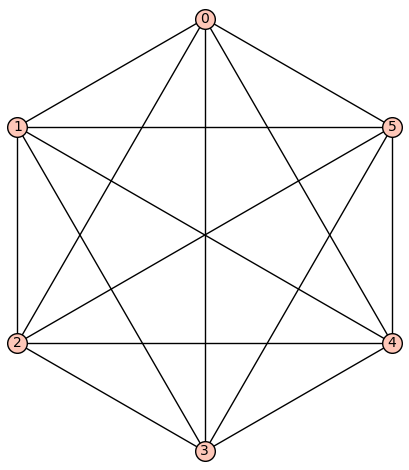

In [57]:
graphs.CompleteGraph(6).plot()

R(3,3) > 5: SAT (coloring exists)


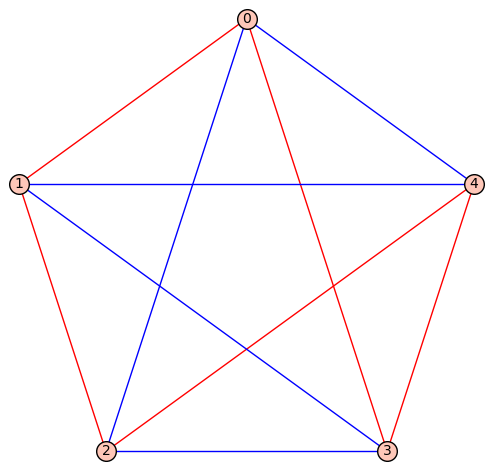

R(3,3) > 6: UNSAT


In [58]:
from itertools import combinations
from pysat.solvers import Cadical195
from pysat.formula import IDPool

def ramsey_gt(n, k, l):
    """Is R(k,l) > n? Returns (model, pool) or None."""
    V = range(n)
    pool = IDPool()

    def edge_var(u,v):
        return pool.id((min(u,v),max(u,v))) # variable encodes the edge from u to v

    cnf = []
    for a,b,c in combinations(V, 3):
        cnf.append([-edge_var(a,b), -edge_var(a,c), -edge_var(b,c)])
        cnf.append([+edge_var(a,b), +edge_var(a,c), +edge_var(b,c)])

    solver = Cadical195(bootstrap_with=cnf)
    if solver.solve():
        model = solver.get_model()
        red_edges  = [(u,v,0) for u,v in combinations(V,2) if  edge_var(u,v) in model]
        blue_edges = [(u,v,1) for u,v in combinations(V,2) if -edge_var(u,v) in model]
        return Graph(red_edges+blue_edges)
    else:
        return None

for n in [5, 6]:
    G = ramsey_gt(n, 3, 3)
    print(f'R(3,3) > {n}: {"SAT (coloring exists)" if G else "UNSAT"}')
    if G:
        G.plot(layout='circular',color_by_label={0:'red',1:'blue'}).show()

---
# SMT — Satisfiability Modulo Theories

SAT + theories: arithmetic, arrays, bitvectors, ...

**Application:** formal verification of algorithms (e.g. bubblesort)

**Example:** Is $x^2 + y^2 = 1 \land x = y \land x > 0$ satisfiable? (unit circle intersecting the line $y=x$)

In [59]:
!sage -pip install z3-solver # install z3 solver

python3(23622) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/38.8 MB ? eta -:--:--

   ╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.5/38.8 MB 5.6 MB/s eta 0:00:07

   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/38.8 MB 11.0 MB/s eta 0:00:04

   ━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/38.8 MB 9.6 MB/s eta 0:00:04

...

   ━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━ 16.3/38.8 MB 12.4 MB/s eta 0:00:02

   ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━ 17.3/38.8 MB 11.7 MB/s eta 0:00:02

   ━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━ 19.9/38.8 MB 11.6 MB/s eta 0:00:02

   ━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━ 21.8/38.8 MB 11.4 MB/s eta 0:00:02

   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 22.8/38.8 MB 11.4 MB/s eta 0:00:02
ERROR: Exception:
Traceback (most recent call last):
  File "/var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 438, in _error_catcher
    yield
  File "/var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 561, in read
    data = self._fp_read(amt) if not fp_closed else b""
           ~~~~~~~~~~~~~^^^^^
  File "/var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/pip/_vendor/urllib3/response.py", line 527, in _fp_read
    return self._fp.read(amt) if amt is not None else self._fp.read()
           ~~~~~~~~~~~~~^^^^^
  File "/var/tmp/sage-10.8-current/local/lib/python3.13/site-packages/pip/_vendor/cachecontrol/filewrapper.py", line 102, in read
    self.__buf.write(data)
    ~~~~~~~~~~~~~~~~^^^^^^
  File "/var/tmp/sage-10.8-current/local/lib/python3.13/tempfile.py", line 500, in func_wrapper
    return f

In [60]:
from z3 import *
x, y = Reals('x y')
s = Solver()
s.add(x**2 + y**2 == 1, x == y, x > 0)
print("satisfiable:",s.check())
print("model:",s.model())

satisfiable: sat
model: [y = 0.7071067811?, x = 0.7071067811?]


More examples in the [Z3 Python tutorial](https://ericpony.github.io/z3py-tutorial/guide-examples.htm)

---

<img src="figs/apc_circ_2018_last.png" width="100%">

Questions? Code & notebook: <a href="https://github.com/manfredscheucher/talk-sageintro">https://github.com/manfredscheucher/talk-sageintro</a>